In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

import sys
sys.path.append('..')
from src.perceptron import Perceptron

In [3]:
def plot_decision_boundary(ax, perceptron, X, y, title, show_misclassified=True):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=['#ff9999', '#9999ff'])
    
    if show_misclassified:
        predictions = perceptron.predict(X)
        correct = predictions == y
        ax.scatter(X[correct & (y == 0), 0], X[correct & (y == 0), 1], 
                  c='red', marker='o', s=50, edgecolors='k', label='Class 0 (correct)')
        ax.scatter(X[correct & (y == 1), 0], X[correct & (y == 1), 1], 
                  c='blue', marker='s', s=50, edgecolors='k', label='Class 1 (correct)')
        ax.scatter(X[~correct & (y == 0), 0], X[~correct & (y == 0), 1], 
                  c='red', marker='x', s=100, linewidths=3, label='Class 0 (wrong)')
        ax.scatter(X[~correct & (y == 1), 0], X[~correct & (y == 1), 1], 
                  c='blue', marker='x', s=100, linewidths=3, label='Class 1 (wrong)')
    else:
        ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='o', s=50, 
                  edgecolors='k', label='Class 0')
        ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='s', s=50, 
                  edgecolors='k', label='Class 1')
    
    if perceptron.weights[1] != 0:
        x_line = np.array([x_min, x_max])
        y_line = -(perceptron.weights[0] * x_line + perceptron.bias) / perceptron.weights[1]
        ax.plot(x_line, y_line, 'k-', linewidth=2, label='Decision boundary')
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.set_title(title)
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)


def visualize_training_evolution(X, y, problem_name, n_epochs=50, learning_rate=0.1):
    perceptron = Perceptron(n_inputs=2, learning_rate=learning_rate, random_state=42)
    perceptron.fit(X, y, n_epochs=n_epochs)
    
    epochs_to_show = [0, 1, 5, 10, 20, len(perceptron.weight_history_) - 1]
    epochs_to_show = [e for e in epochs_to_show if e < len(perceptron.weight_history_)]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, epoch in enumerate(epochs_to_show):
        if idx >= len(axes):
            break
        
        temp_perceptron = Perceptron(n_inputs=2, learning_rate=learning_rate, random_state=42)
        temp_perceptron.weights = perceptron.weight_history_[epoch]['weights']
        temp_perceptron.bias = perceptron.weight_history_[epoch]['bias']
        
        errors = perceptron.errors_[epoch - 1] if epoch > 0 else len(X)
        plot_decision_boundary(axes[idx], temp_perceptron, X, y, 
                             f'Epoch {epoch} (Errors: {errors})')
    
    plt.suptitle(f'{problem_name} - Decision Boundary Evolution', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig, perceptron


def visualize_convergence(perceptrons_dict):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for name, perceptron in perceptrons_dict.items():
        ax.plot(range(len(perceptron.errors_)), perceptron.errors_, 
               marker='o', label=name, linewidth=2)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Number of Errors', fontsize=12)
    ax.set_title('Convergence Comparison', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    return fig

X_class, y_class = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
)

X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
X_and_noisy = X_and + np.random.randn(*X_and.shape) * 0.1

X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])
X_or_noisy = X_or + np.random.randn(*X_or.shape) * 0.1

X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])
X_xor_noisy = X_xor + np.random.randn(*X_xor.shape) * 0.1

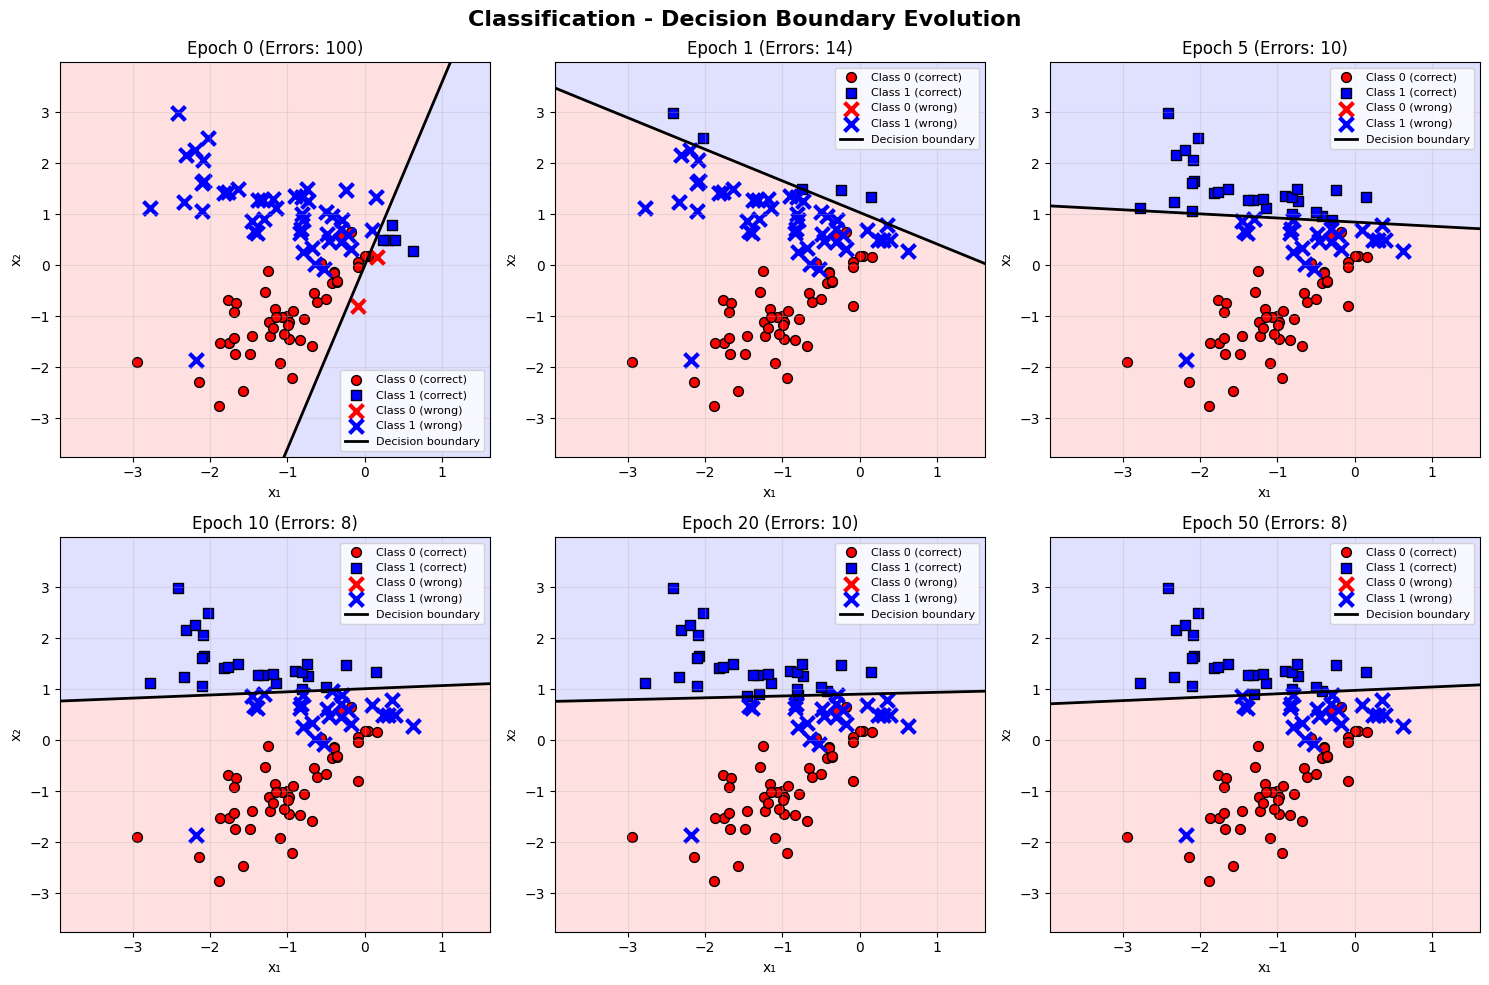

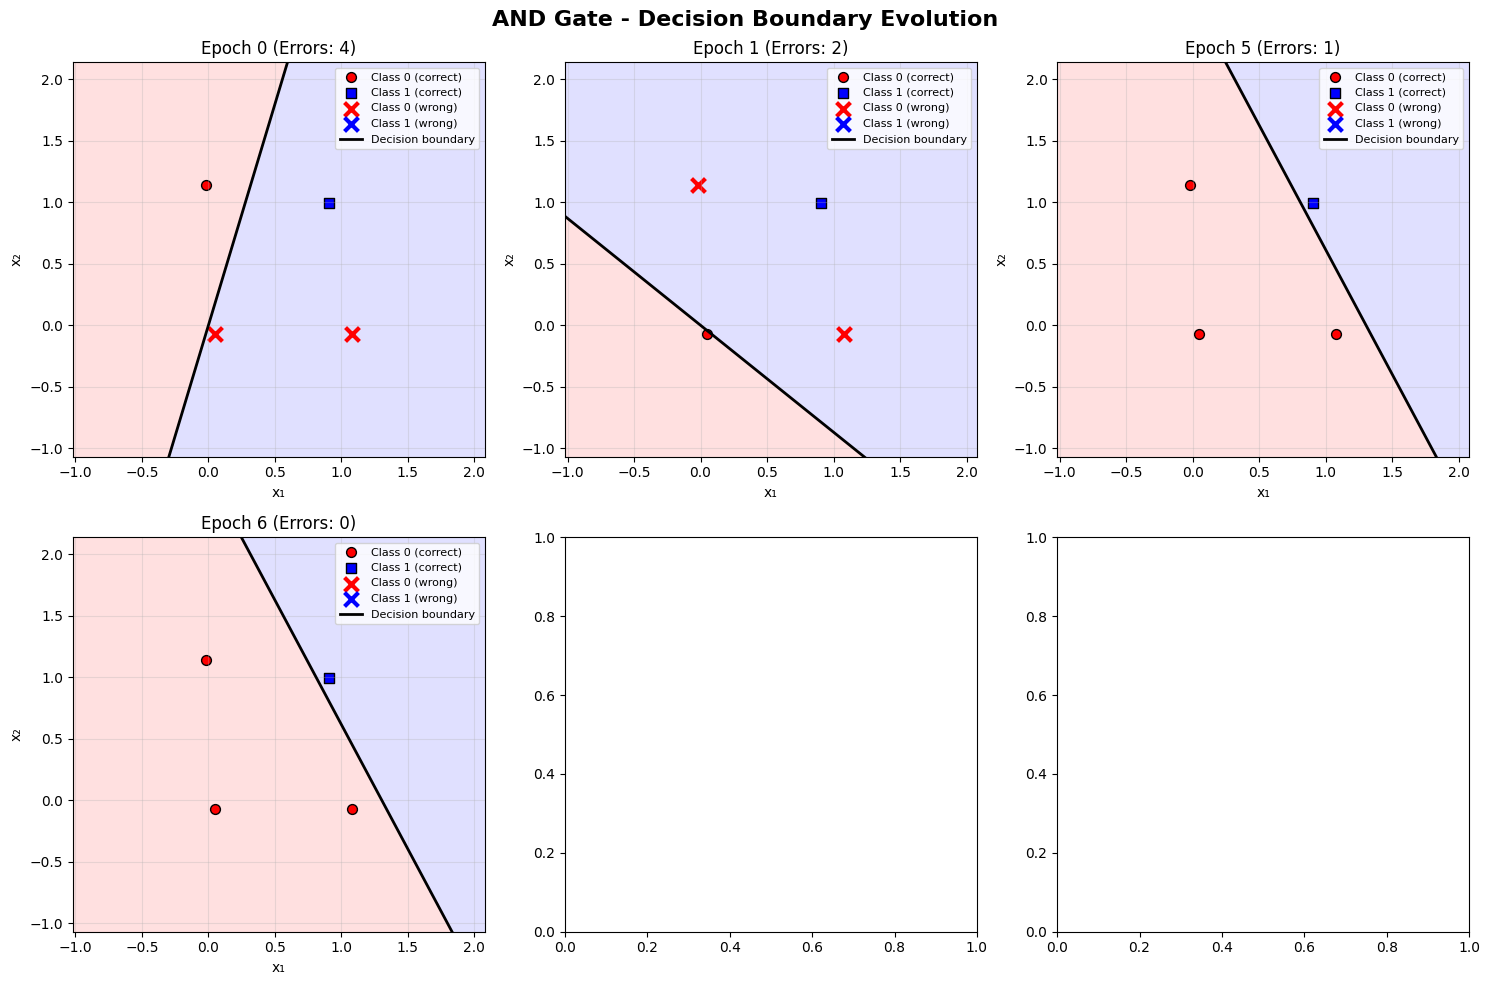

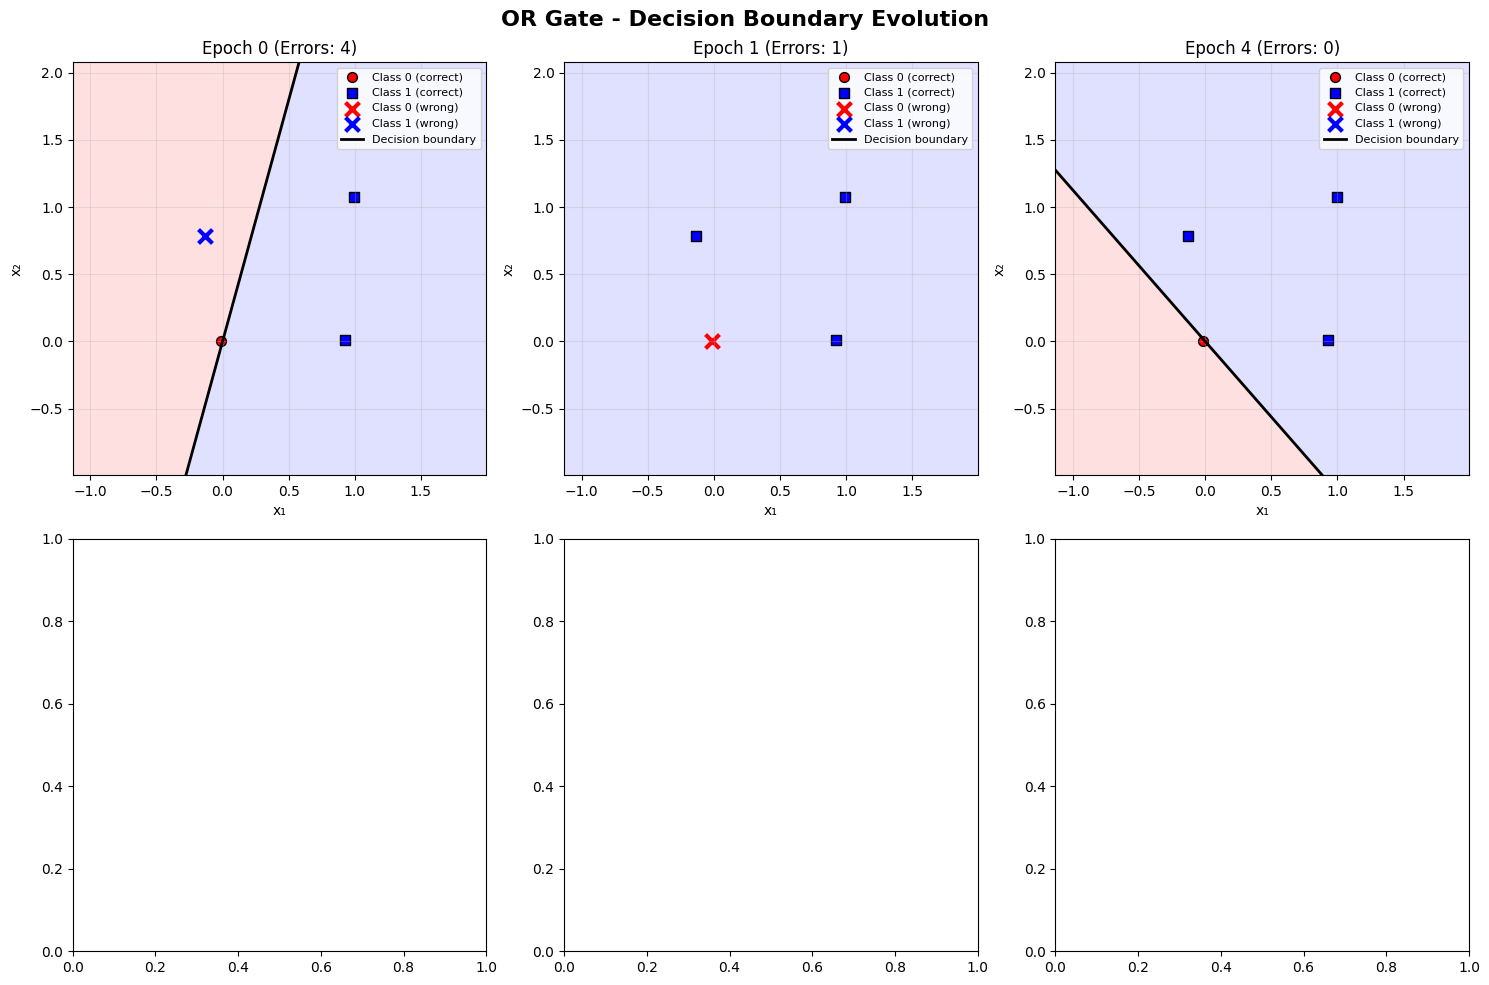

   Final errors: 4 (never converges)


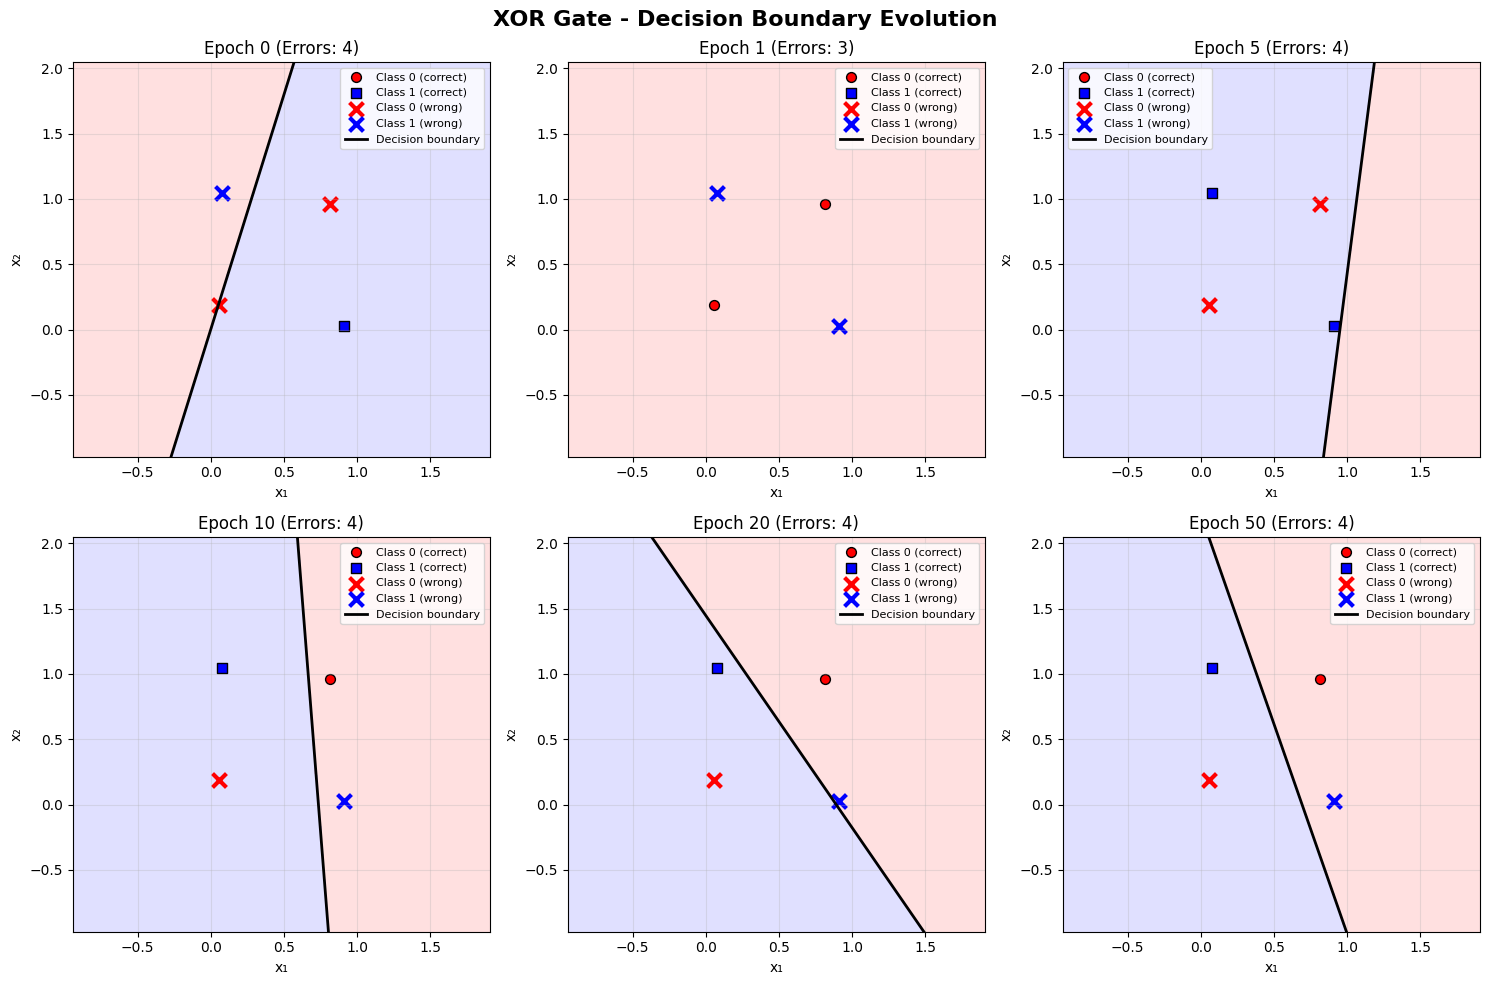

In [4]:
fig1, p1 = visualize_training_evolution(X_class, y_class, "Classification", n_epochs=50)
plt.show()
fig2, p2 = visualize_training_evolution(X_and_noisy, y_and, "AND Gate", n_epochs=50)
plt.show()
fig3, p3 = visualize_training_evolution(X_or_noisy, y_or, "OR Gate", n_epochs=50)
plt.show()
fig4, p4 = visualize_training_evolution(X_xor_noisy, y_xor, "XOR Gate", n_epochs=50)
print(f"   Final errors: {p4.errors_[-1]} (never converges)")
plt.show()


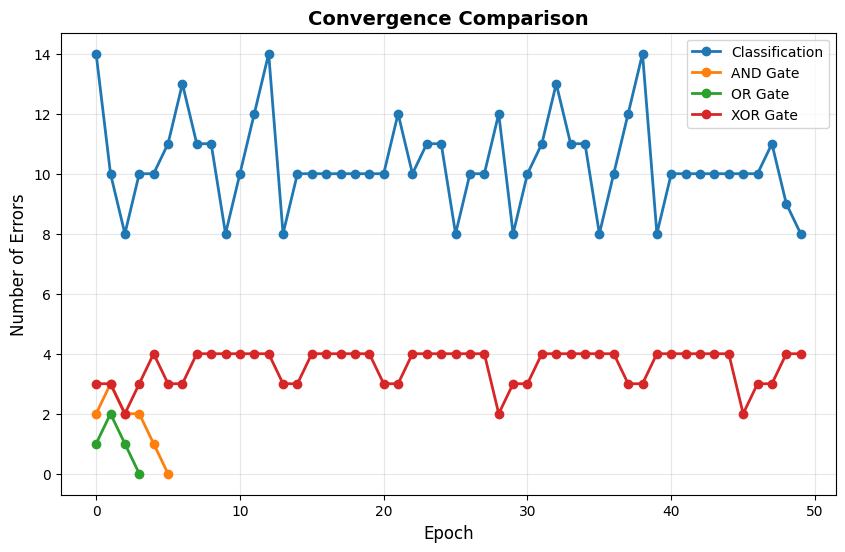

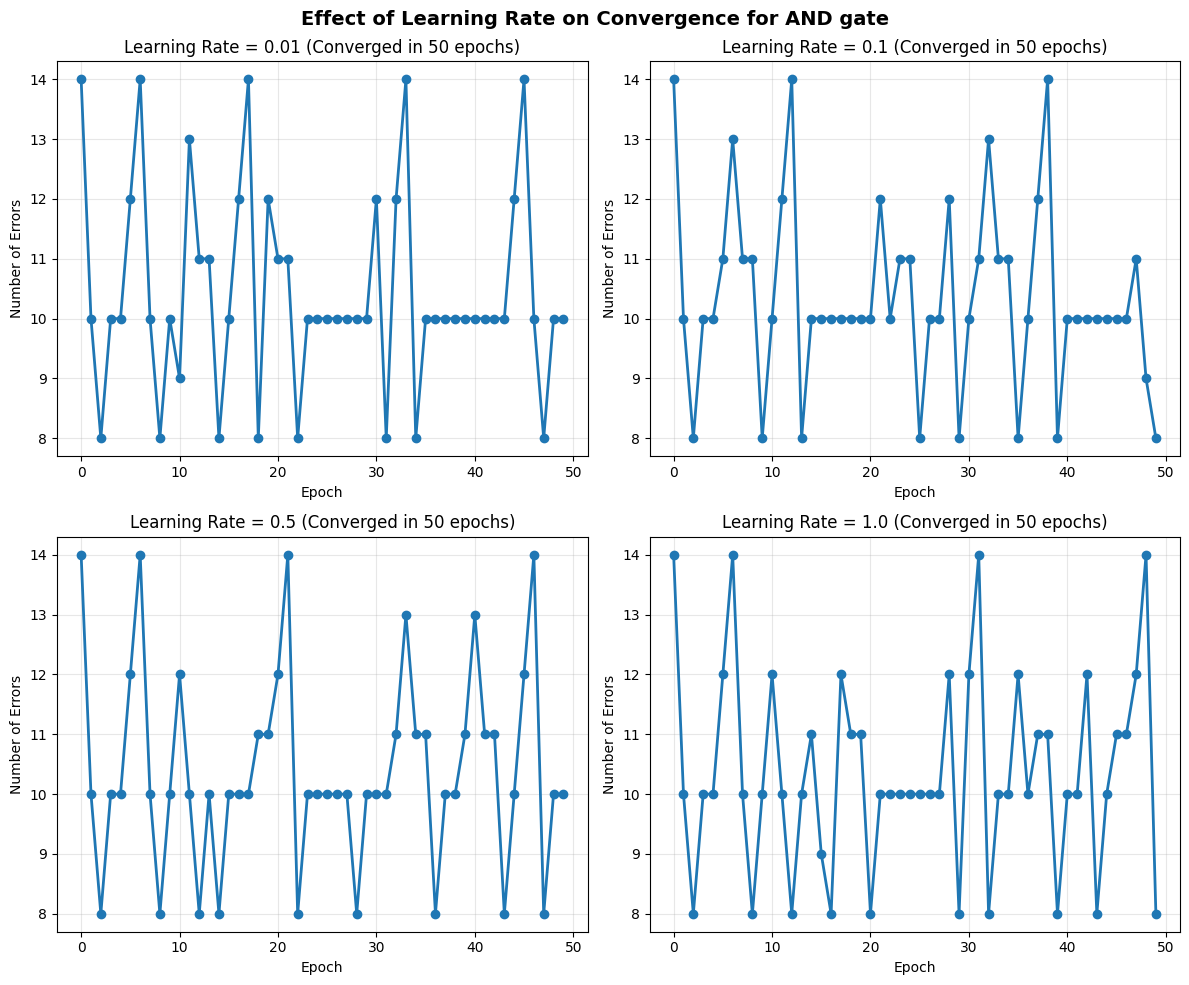

In [5]:
fig5 = visualize_convergence({
    'Classification': p1,
    'AND Gate': p2,
    'OR Gate': p3,
    'XOR Gate': p4
})

fig6, axes = plt.subplots(2, 2, figsize=(12, 10))
learning_rates = [0.01, 0.1, 0.5, 1.0]

for idx, lr in enumerate(learning_rates):
    ax = axes[idx // 2, idx % 2]
    p = Perceptron(n_inputs=2, learning_rate=lr, random_state=42)
    p.fit(X_class, y_class, n_epochs=50)
    ax.plot(range(len(p.errors_)), p.errors_, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Number of Errors')
    ax.set_title(f'Learning Rate = {lr} (Converged in {len(p.errors_)} epochs)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Learning Rate on Convergence for AND gate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1. - AND Gate: 9 epochs
   - OR Gate: 4 epochs
   - Classification: 13 epochs

2. The decision boundary keeps oscillating, trying to separate points
   that cannot be separated by a single line.

3. For this problem smallest learning rate works the best but it may not always be the case

4. Perceptron never converges and decision boundary keeps shifting without finding a solution